In [34]:
import pymcel as pc
import numpy as np
import matplotlib.pyplot as plt
from celluloid import Camera
from IPython.display import HTML
from scipy.integrate import solve_ivp


In [35]:
deg = np.pi/180
rad = 180/np.pi

In [ ]:
def edm_pendulo_simple(t,Ys,g,L):
    teta, u, = Ys
    dteta_dt = u
    du_dt = -g/L*np.sin(teta)
    return np.array([dteta_dt, du_dt])

In [61]:
ts = np.linspace(0,10,100)
Y0s = [40*deg,0]
g = 9.81
L = 1
sol = solve_ivp(edm_pendulo_simple, [ts[0],ts[-1]], Y0s, t_eval=ts, args=(g,L))

In [62]:
#Variables de configuración
tetas = sol.y[0]
us = sol.y[1]

In [63]:
xs = L*np.sin(tetas)
ys = -L*np.cos(tetas)

(np.float64(-0.7052356451580338),
 np.float64(0.7069791932505666),
 np.float64(-1.011687720486852),
 np.float64(-0.7543471441966983))

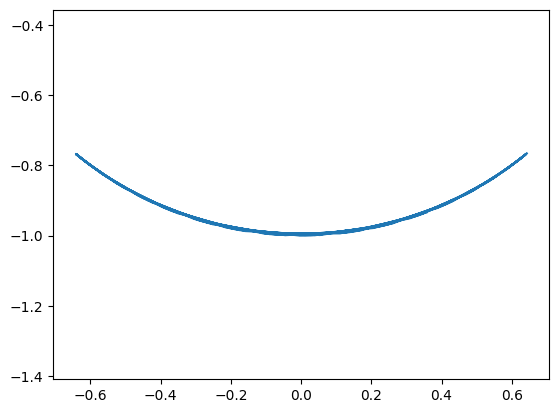

In [64]:
plt.plot(xs,ys)
plt.axis('equal')

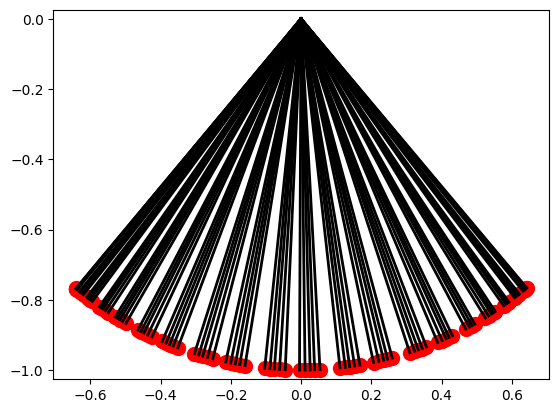

In [65]:
fig = plt.figure()
camera = Camera(fig)

for i,t in enumerate(ts):
    plt.plot([0,xs[i]],[0,ys[i]],color='black',lw=2)
    plt.scatter(xs[i],ys[i],color='red',s=100)
    plt.axis('equal')
    camera.snap()

In [66]:
anim = camera.animate()
HTML(anim.to_jshtml())